In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos para que se vean modernos
sns.set_theme(style="whitegrid", palette="muted")

# 1. Cargar el dataset
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(url)

# 2. Limpieza de datos (Eliminamos filas con valores nulos para evitar errores)
df_clean = df.dropna().copy()

# 3. Estandarizar la columna de sexo (para evitar el error que tuvimos antes)
# Convertimos todo a minúsculas y eliminamos espacios en blanco por seguridad
df_clean['sex'] = df_clean['sex'].str.lower().str.strip()

print(f"Dataset original: {df.shape[0]} pingüinos.")
print(f"Dataset limpio (listo para análisis): {df_clean.shape[0]} pingüinos.")
display(df_clean.head())

Dataset original: 344 pingüinos.
Dataset limpio (listo para análisis): 333 pingüinos.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


--- Resumen Estadístico de Medidas Físicas ---


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.00,333.00,333.00,333.00,333.00
mean,43.99,17.16,200.97,4207.06,2008.04
std,5.47,1.97,14.02,805.22,0.81
min,32.10,13.10,172.00,2700.00,2007.00
25%,39.50,15.60,190.00,3550.00,2007.00
50%,44.50,17.30,197.00,4050.00,2008.00
75%,48.60,18.70,213.00,4775.00,2009.00
max,59.60,21.50,231.00,6300.00,2009.00


/tmp/ipykernel_458/509795305.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='species', ax=axes[0], palette='viridis')


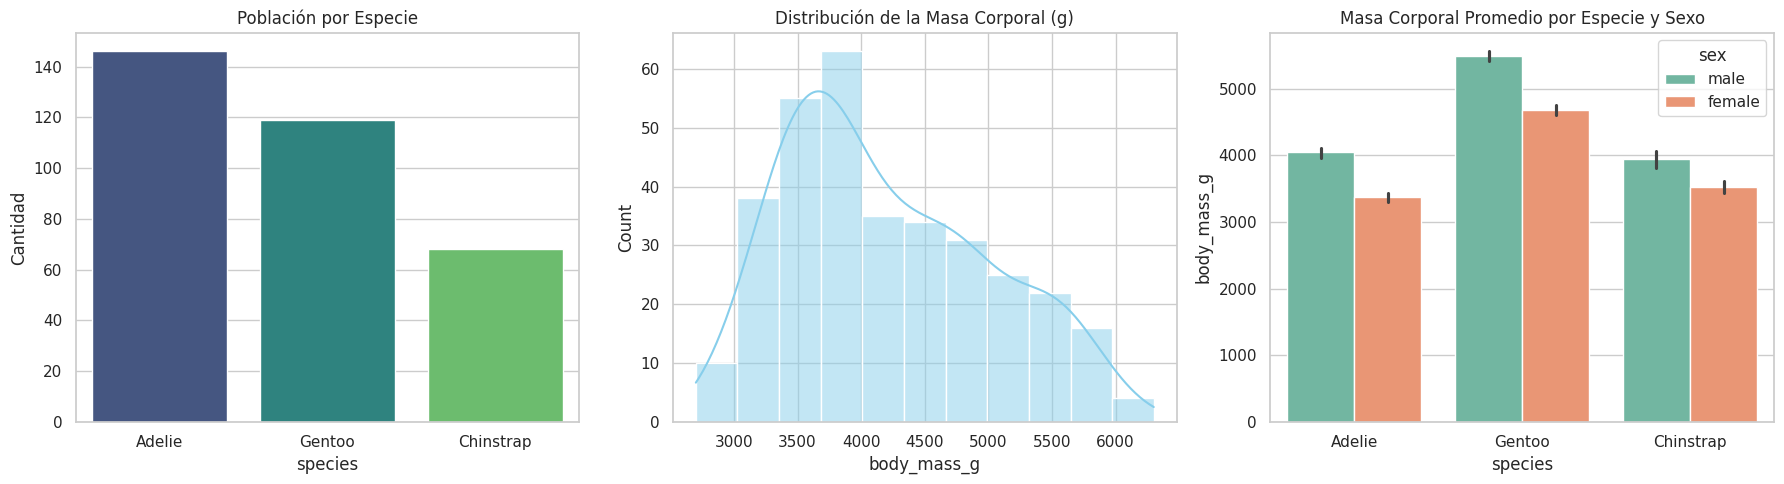

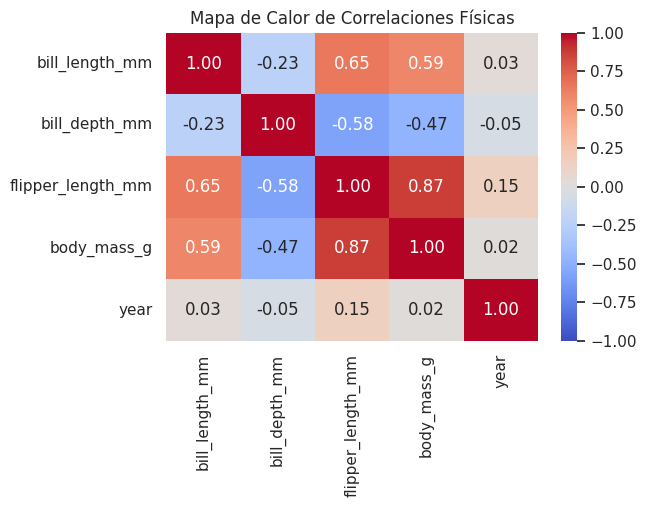

In [6]:
# 1. Tabla de Estadística Descriptiva
print("--- Resumen Estadístico de Medidas Físicas ---")
display(df_clean.describe().round(2))

# 2. Configurar una figura con múltiples gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: Cantidad de pingüinos por especie
sns.countplot(data=df_clean, x='species', ax=axes[0], palette='viridis')
axes[0].set_title('Población por Especie')
axes[0].set_ylabel('Cantidad')

# Gráfico B: Distribución del Peso
sns.histplot(data=df_clean, x='body_mass_g', kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribución de la Masa Corporal (g)')

# Gráfico C: Peso promedio por sexo y especie
sns.barplot(data=df_clean, x='species', y='body_mass_g', hue='sex', ax=axes[2], palette='Set2')
axes[2].set_title('Masa Corporal Promedio por Especie y Sexo')

plt.tight_layout()
plt.show()

# 3. Matriz de Correlación (¿Qué variables se relacionan más?)
plt.figure(figsize=(6, 4))
# Seleccionamos solo las columnas numéricas
cols_numericas = df_clean.select_dtypes(include=[np.number])
sns.heatmap(cols_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlaciones Físicas')
plt.show()

R^2 (Explicación de varianza): 0.77
Margen de error promedio (MAE): +/- 286.92 gramos


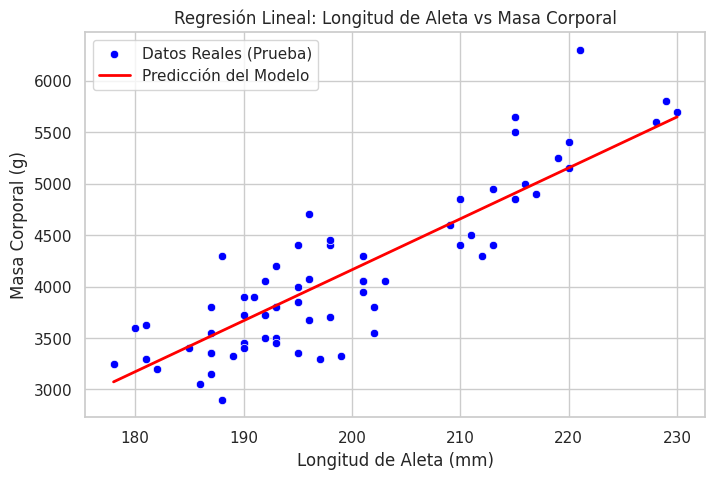

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Variables
X_lin = df_clean[['flipper_length_mm']] # Predictora
y_lin = df_clean['body_mass_g']         # Objetivo

# 2. División de datos (80% para entrenar, 20% para probar)
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

# 3. Entrenar Modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_lin, y_train_lin)

# 4. Predicciones y Evaluación
predicciones_lin = modelo_lineal.predict(X_test_lin)
r2 = r2_score(y_test_lin, predicciones_lin)
mae = mean_absolute_error(y_test_lin, predicciones_lin)

print(f"R^2 (Explicación de varianza): {r2:.2f}")
print(f"Margen de error promedio (MAE): +/- {mae:.2f} gramos")

# 5. Gráfico para la presentación (Línea de tendencia)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_test_lin['flipper_length_mm'], y=y_test_lin, color='blue', label='Datos Reales (Prueba)')
sns.lineplot(x=X_test_lin['flipper_length_mm'], y=predicciones_lin, color='red', linewidth=2, label='Predicción del Modelo')
plt.title('Regresión Lineal: Longitud de Aleta vs Masa Corporal')
plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')
plt.legend()
plt.show()

--- Precisión General del Modelo ---
Exactitud (Accuracy): 86.6%

--- Reporte Detallado ---
              precision    recall  f1-score   support

      Hembra       0.91      0.83      0.87        36
       Macho       0.82      0.90      0.86        31

    accuracy                           0.87        67
   macro avg       0.87      0.87      0.87        67
weighted avg       0.87      0.87      0.87        67



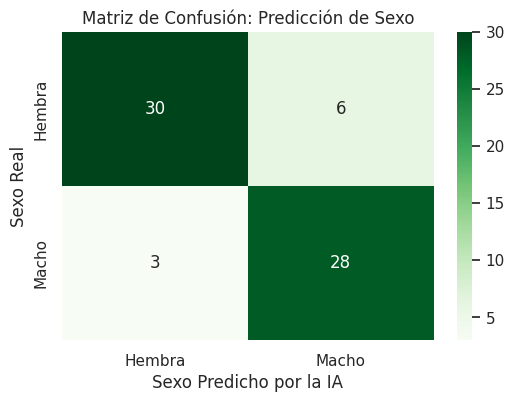

,Variable,Importancia (Coeficientes)
2,bill_depth_mm,3.118810
0,body_mass_g,3.103699
1,bill_length_mm,0.474906


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 1. Convertir sexo a 1 (Macho) y 0 (Hembra) de forma segura
df_clean['sex_binary'] = df_clean['sex'].map({'male': 1, 'female': 0})
df_log = df_clean.dropna(subset=['sex_binary'])

# 2. Variables (Usaremos peso y medidas del pico)
X_log = df_log[['body_mass_g', 'bill_length_mm', 'bill_depth_mm']]
y_log = df_log['sex_binary']

# 3. División de datos
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

# Opcional pero recomendado: Escalar los datos (mejora la regresión logística)
scaler = StandardScaler()
X_train_log_scaled = scaler.fit_transform(X_train_log)
X_test_log_scaled = scaler.transform(X_test_log)

# 4. Entrenar el modelo
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train_log_scaled, y_train_log)

# 5. Predicciones
pred_log = modelo_logistico.predict(X_test_log_scaled)

# 6. Reporte de Resultados
print("--- Precisión General del Modelo ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test_log, pred_log) * 100:.1f}%\n")

print("--- Reporte Detallado ---")
print(classification_report(y_test_log, pred_log, target_names=['Hembra', 'Macho']))

# 7. Matriz de Confusión visual
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test_log, pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Hembra', 'Macho'], yticklabels=['Hembra', 'Macho'])
plt.title('Matriz de Confusión: Predicción de Sexo')
plt.ylabel('Sexo Real')
plt.xlabel('Sexo Predicho por la IA')
plt.show()

# 8. Importancia de las variables (¿Qué se fija la IA para decidir?)
importancias = pd.DataFrame({'Variable': X_log.columns, 'Importancia (Coeficientes)': modelo_logistico.coef_[0]})
importancias = importancias.sort_values(by='Importancia (Coeficientes)', ascending=False)
display(importancias)